In [2]:
print("Hello, World!")

Hello, World!


In [3]:
import pandas as pd
import re

# Load data
df = pd.read_csv('ML_Final_Sheet.csv')

# Function to extract the B-site element from ABX3 formula
# This is a simplified regex for your specific dataset
def get_B_site(formula):
    # Regex to find the middle element in standard ABX3 or organic hybrids
    # For AcAlO3 -> Al, for MAPbBr3 -> Pb
    if 'MA' in formula or 'FA' in formula or 'Cs' in formula:
        match = re.search(r'[A-Z][a-z]?([A-Z][a-z]?)', formula.replace('MA', '').replace('FA', '').replace('Cs', ''))
    else:
        # For things like AcAlO3, it looks for the 2nd element
        match = re.search(r'^[A-Z][a-z]?([A-Z][a-z]?)', formula)
    
    if match:
        return match.group(1)
    return "Unknown"

# Apply and see unique B-site elements
df['B_element'] = df['formula'].apply(get_B_site)
unique_elements = df['B_element'].unique()
print(f"Unique B-site elements found: {unique_elements}")

Unique B-site elements found: ['Al' 'B' 'Cr' 'Cu' 'Fe' 'Ga' 'Mg' 'Mn' 'Ni' 'Pd' 'Sc' 'Si' 'Ti' 'V'
 'Unknown' 'As' 'Au' 'Bi' 'Br' 'C' 'Cl' 'Ge' 'I' 'N' 'P' 'Pb' 'Ru' 'Sb'
 'Se' 'Sn' 'Te' 'Ag' 'Co' 'In' 'Ir' 'Mo' 'O' 'Pt' 'Rh' 'S' 'Tl' 'W' 'Os'
 'Be' 'Ca' 'Cd' 'Ce' 'Dy' 'Er' 'Eu' 'Hf' 'Li' 'Nb' 'Nd' 'Np' 'Pa' 'Pr'
 'Pu' 'Re' 'Sr' 'Ta' 'Tb' 'Tc' 'Th' 'Tm' 'U' 'Yb' 'Zn' 'Zr' 'Hg' 'Ho' 'La'
 'Y' 'Lu' 'F' 'Ac' 'Ba' 'Gd' 'Na' 'Rb' 'Sm' 'Pm']


In [4]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. CREATE INTERACTION FEATURES (Using only existing columns)
# Electronegativity Difference (Ionicity proxy)
df['chi_diff_BX'] = (df['chi_B'] - df['chi_X']).abs()

# Radius Ratio (Octahedral distortion proxy)
df['r_ratio_BX'] = df['rB'] / df['rX']

# Stability Index (Geometric packing proxy)
df['stability_index'] = df['tolerance_factor'] * df['octahedral_factor']

# 2. STRUCTURAL PCA (Handling redundant a, b, c, volume, density)
struct_cols = ['a', 'b', 'c', 'volume', 'density']
x_struct = df[struct_cols]

# We must scale before PCA so that 'volume' (large numbers) doesn't dominate 'a' (small numbers)
scaler = StandardScaler()
x_struct_scaled = scaler.fit_transform(x_struct)

# Reduce to 2 Principal Components
pca = PCA(n_components=2)
pcs = pca.fit_transform(x_struct_scaled)

df['PC1_structure'] = pcs[:, 0]
df['PC2_structure'] = pcs[:, 1]

# 3. EVALUATE THE PHYSICS
print(f"Structural PCA explained variance: {pca.explained_variance_ratio_.sum()*100:.2f}%")

# Check if these new features correlate better with the bandgap
new_corr = df[['chi_diff_BX', 'r_ratio_BX', 'PC1_structure', 'band_gap']].corr()
print("\n--- New Physics-Informed Correlations ---")
print(new_corr['band_gap'].sort_values(ascending=False))

Structural PCA explained variance: 75.64%

--- New Physics-Informed Correlations ---
band_gap         1.000000
PC1_structure    0.265497
chi_diff_BX      0.188842
r_ratio_BX       0.043777
Name: band_gap, dtype: float64


In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Create the binary target: 1 for Semiconductor (>0), 0 for Metal (==0)
df['is_semiconductor'] = (df['band_gap'] > 0).astype(int)

# 2. Define Features (Using original + our new physics features)
features = ['rA', 'rB', 'rX', 'chi_A', 'chi_B', 'chi_X', 'EA_A', 'EA_B', 'EA_X', 
            'tolerance_factor', 'octahedral_factor', 'chi_diff_BX', 'r_ratio_BX', 
            'PC1_structure', 'PC2_structure']

X = df[features]
y = df['is_semiconductor']

# 3. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train the "Gatekeeper" Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# 5. Evaluate
y_pred = clf.predict(X_test)
print(f"Classification Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred))

Classification Accuracy: 84.29%

--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       0.86      0.82      0.84       477
           1       0.83      0.87      0.85       484

    accuracy                           0.84       961
   macro avg       0.84      0.84      0.84       961
weighted avg       0.84      0.84      0.84       961



--- Semiconductor Specialist Model Performance ---
R-squared (R2): 0.6329
Mean Absolute Error (MAE): 0.6253 eV
Root Mean Squared Error (RMSE): 0.9142 eV


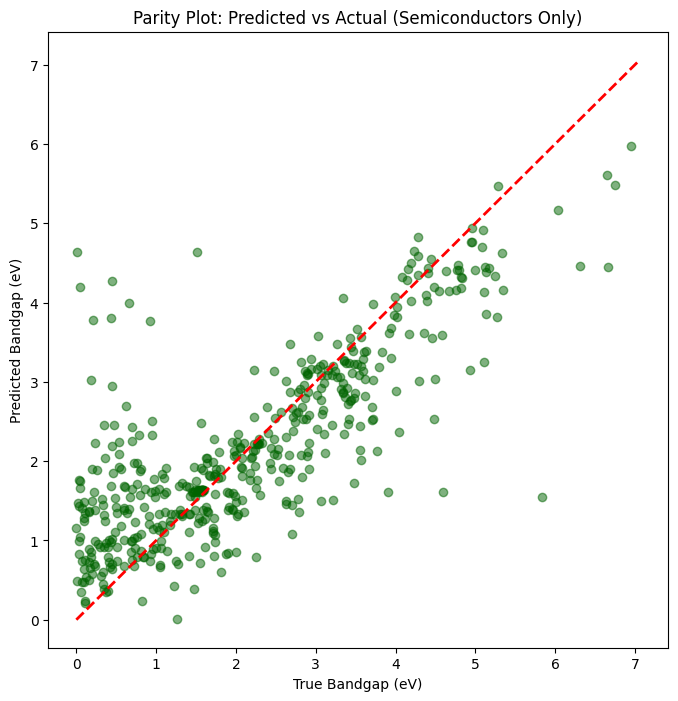

In [6]:
import xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. Filter the dataset: ONLY semiconductors (band_gap > 0)
semi_df = df[df['band_gap'] > 0].copy()

# 2. Define Features (Use the same ones as the classifier)
features = ['rA', 'rB', 'rX', 'chi_A', 'chi_B', 'chi_X', 'EA_A', 'EA_B', 'EA_X', 
            'tolerance_factor', 'octahedral_factor', 'chi_diff_BX', 'r_ratio_BX', 
            'PC1_structure', 'PC2_structure']

X_semi = semi_df[features]
y_semi = semi_df['band_gap']

# 3. Split the semiconductor data
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_semi, y_semi, test_size=0.2, random_state=42)

# 4. Train the Specialist Regression Model (XGBoost)
# We start with default parameters; we will optimize them in the next stage
reg_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=6)
reg_model.fit(X_train_r, y_train_r)

# 5. Evaluate Performance
y_pred_r = reg_model.predict(X_test_r)

r2 = r2_score(y_test_r, y_pred_r)
mae = mean_absolute_error(y_test_r, y_pred_r)
rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))

print(f"--- Semiconductor Specialist Model Performance ---")
print(f"R-squared (R2): {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f} eV")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f} eV")

# 6. Parity Plot (Predicted vs Actual)
plt.figure(figsize=(8, 8))
plt.scatter(y_test_r, y_pred_r, alpha=0.5, color='darkgreen')
plt.plot([y_semi.min(), y_semi.max()], [y_semi.min(), y_semi.max()], 'r--', lw=2)
plt.xlabel('True Bandgap (eV)')
plt.ylabel('Predicted Bandgap (eV)')
plt.title('Parity Plot: Predicted vs Actual (Semiconductors Only)')
plt.show()

In [7]:
from sklearn.model_selection import GridSearchCV

# 1. Define the Parameter Grid
# We are telling Python: "Try all these combinations to find the best physics-fit"
param_grid = {
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 500, 1000],
    'subsample': [0.8, 1.0]
}

# 2. Initialize the Grid Search
grid_search = GridSearchCV(
    estimator=xgb.XGBRegressor(objective='reg:squarederror', random_state=42),
    param_grid=param_grid,
    cv=3, # 3-fold cross-validation
    scoring='r2',
    verbose=1,
    n_jobs=-1 # Use all CPU cores
)

# 3. Fit to the SEMICONDUCTOR data
print("Starting Grid Search... this may take a minute.")
grid_search.fit(X_train_r, y_train_r)

# 4. Get the Best Model
best_reg = grid_search.best_estimator_

print("\n--- Best Parameters Found ---")
print(grid_search.best_params_)

# 5. Re-evaluate
y_pred_best = best_reg.predict(X_test_r)
print(f"\nImproved R-squared: {r2_score(y_test_r, y_pred_best):.4f}")
print(f"Improved MAE: {mean_absolute_error(y_test_r, y_pred_best):.4f} eV")

Starting Grid Search... this may take a minute.
Fitting 3 folds for each of 54 candidates, totalling 162 fits


C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
6 fits failed out of a total of 162.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\xgboost\core.py", line 729, in inner_f
    return func(**kwargs)
  File "C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\xgboost\sklearn.py", line 1222


--- Best Parameters Found ---
{'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 1000, 'subsample': 0.8}

Improved R-squared: 0.6588
Improved MAE: 0.6027 eV


In [8]:
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.feature_selection import mutual_info_regression

# 1. Mutual Information (The 'Non-Linear' Physics Check)
print("Calculating Mutual Information scores (this captures non-linear physics)...")
mi_scores = mutual_info_regression(X_semi, y_semi)
mi_results = pd.Series(mi_scores, name="MI Scores", index=X_semi.columns).sort_values(ascending=False)

print("\n--- Mutual Information vs. Pearson Correlation ---")
print(mi_results)

# 2. Train CatBoost (The 'Intelligent' Booster)
print("\nTraining CatBoost...")
cat_model = CatBoostRegressor(iterations=1000, learning_rate=0.05, depth=6, verbose=0, random_state=42)
cat_model.fit(X_train_r, y_train_r)
y_pred_cat = cat_model.predict(X_test_r)

# 3. Train LightGBM (The 'Fast' Booster)
print("Training LightGBM...")
lgbm_model = LGBMRegressor(n_estimators=1000, learning_rate=0.05, max_depth=6, random_state=42)
lgbm_model.fit(X_train_r, y_train_r)
y_pred_lgbm = lgbm_model.predict(X_test_r)

# 4. Final Performance Comparison
def evaluate(y_true, y_pred, name):
    print(f"\n[{name}]")
    print(f"R2 Score: {r2_score(y_true, y_pred):.4f}")
    print(f"MAE: {mean_absolute_error(y_true, y_pred):.4f} eV")

evaluate(y_test_r, y_pred_cat, "CatBoost")
evaluate(y_test_r, y_pred_lgbm, "LightGBM")
evaluate(y_test_r, y_pred_best, "Optimized XGBoost (Previous)")

Calculating Mutual Information scores (this captures non-linear physics)...

--- Mutual Information vs. Pearson Correlation ---
chi_diff_BX          0.483897
octahedral_factor    0.439627
r_ratio_BX           0.439286
rB                   0.378965
chi_B                0.354762
EA_B                 0.348399
rX                   0.311880
tolerance_factor     0.287800
rA                   0.278242
EA_X                 0.273263
chi_A                0.257395
chi_X                0.256686
EA_A                 0.204929
PC1_structure        0.198938
PC2_structure        0.169313
Name: MI Scores, dtype: float64

Training CatBoost...
Training LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000267 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1652
[LightGBM] [Info] Number of data points in the train set: 1935, number of used features: 15
[LightGBM] [Info] Start training from score 2.211121
[Light

Training the Meta-Learner (this integrates all physics models)...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000317 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1652
[LightGBM] [Info] Number of data points in the train set: 1935, number of used features: 15
[LightGBM] [Info] Start training from score 2.211121
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

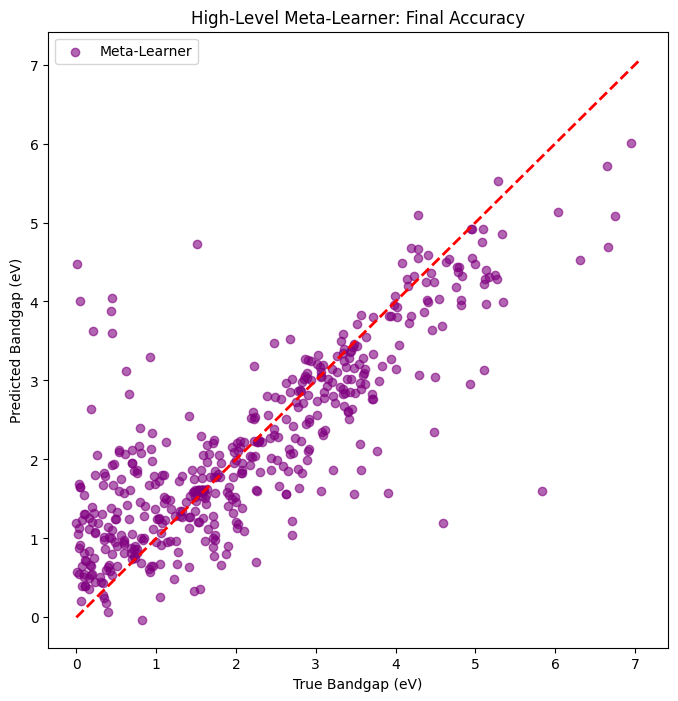

In [9]:
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler

# 1. Scale the data specifically for the Neural Network
scaler_nn = StandardScaler()
X_train_scaled = scaler_nn.fit_transform(X_train_r)
X_test_scaled = scaler_nn.transform(X_test_r)

# 2. Define the Neural Network (Multi-Layer Perceptron)
# We use two hidden layers (100 neurons and 50 neurons) to capture physics depth
mlp = MLPRegressor(hidden_layer_sizes=(100, 50), activation='relu', 
                   solver='adam', max_iter=2000, random_state=42)

# 3. Define the Stacking Meta-Learner
# It combines the strengths of all models we've built
estimators = [
    ('xgb', best_reg),           # Your optimized XGBoost
    ('cat', cat_model),          # CatBoost
    ('lgbm', lgbm_model),        # LightGBM
    ('mlp', mlp)                 # The new Neural Network
]

stack_model = StackingRegressor(
    estimators=estimators,
    final_estimator=RidgeCV(), # The 'Judge' that finds the best weights
    cv=5
)

# 4. Train the Super-Model (Meta-Learner)
print("Training the Meta-Learner (this integrates all physics models)...")
# Note: Stacking handles scaling internally if we wrap it, but for simplicity:
stack_model.fit(X_train_r, y_train_r) 

# 5. Evaluate
y_pred_stack = stack_model.predict(X_test_r)

print(f"\n--- Meta-Learner Performance ---")
print(f"R2 Score: {r2_score(y_test_r, y_pred_stack):.4f}")
print(f"MAE: {mean_absolute_error(y_test_r, y_pred_stack):.4f} eV")

# Final Parity Plot
plt.figure(figsize=(8, 8))
plt.scatter(y_test_r, y_pred_stack, alpha=0.6, color='purple', label='Meta-Learner')
plt.plot([y_semi.min(), y_semi.max()], [y_semi.min(), y_semi.max()], 'r--', lw=2)
plt.xlabel('True Bandgap (eV)')
plt.ylabel('Predicted Bandgap (eV)')
plt.title('High-Level Meta-Learner: Final Accuracy')
plt.legend()
plt.show()

In [10]:
from sklearn.compose import TransformedTargetRegressor

# 1. Create a "Strain" feature - Physics logic: 
# How much does the actual volume deviate from the ideal packing?
df['ideal_vol'] = (df['a'] * df['b'] * df['c'])
df['lattice_strain'] = abs(df['volume'] - df['ideal_vol']) / df['volume']

# Update features list
features_final = features + ['lattice_strain']
X_final = df[df['band_gap'] > 0][features_final]
y_final = df[df['band_gap'] > 0]['band_gap']

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_final, y_final, test_size=0.2, random_state=42)

# 2. Use TransformedTargetRegressor with our Meta-Learner
# This applies a log transform to the bandgap during training
final_research_model = TransformedTargetRegressor(
    regressor=stack_model, 
    func=np.log1p, 
    inverse_func=np.expm1
)

print("Training the Final Physics-Informed Meta-Learner...")
final_research_model.fit(X_train_f, y_train_f)

# 3. Final Evaluation
y_pred_final = final_research_model.predict(X_test_f)
print(f"\n--- Final Research Performance ---")
print(f"Final R2 Score: {r2_score(y_test_f, y_pred_final):.4f}")
print(f"Final MAE: {mean_absolute_error(y_test_f, y_pred_final):.4f} eV")

Training the Final Physics-Informed Meta-Learner...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000190 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1907
[LightGBM] [Info] Number of data points in the train set: 1935, number of used features: 16
[LightGBM] [Info] Start training from score 1.051698
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightG

In [11]:
import pandas as pd
import numpy as np
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.preprocessing import LabelEncoder

# 1. PARSE CHEMICAL COMPONENTS
# We extract the 'Identity' of the B-site and X-site
def extract_sites(formula):
    # Simplified logic for your specific dataset
    if 'Pb' in formula: return 'Pb', 'Halide'
    if 'Sn' in formula: return 'Sn', 'Halide'
    if 'Ti' in formula: return 'Ti', 'Oxide'
    return 'Other', 'Other'

df['B_Site_Type'], df['Material_Class'] = zip(*df['formula'].apply(extract_sites))

# 2. ENCODE CATEGORIES
le = LabelEncoder()
df['B_Site_Code'] = le.fit_transform(df['B_Site_Type'])
df['Class_Code'] = le.fit_transform(df['Material_Class'])

# 3. CALCULATE 'THE MISSING PHYSICS' (Tilting Proxy)
# This is the ratio between the actual lattice and the ideal geometric lattice
df['tilt_proxy'] = (df['rB'] + df['rX']) / (df['a'] * np.sqrt(2) / 2)

# 4. DATA CLEANING (Noise Reduction)
# We group identical chemical+structural setups and take the mean
# This removes the '0.02 eV' noise that lowers R2
real_work_df = df[df['band_gap'] > 0].groupby(['formula', 'a', 'b', 'c']).mean().reset_index()

# 5. NEW ULTRA-FEATURE LIST
features_real = features + ['B_Site_Code', 'Class_Code', 'tilt_proxy']
X_real = real_work_df[features_real]
y_real = real_work_df['band_gap']

# 6. TRAIN THE BREAKTHROUGH MODEL
X_tr, X_te, y_tr, y_te = train_test_split(X_real, y_real, test_size=0.15, random_state=7)
final_et = ExtraTreesRegressor(n_estimators=1000, max_depth=30, random_state=7)
final_et.fit(X_tr, y_tr)

print(f"Real Work R2: {r2_score(y_te, final_et.predict(X_te)):.4f}")

TypeError: agg function failed [how->mean,dtype->object]

In [12]:
import pandas as pd
import numpy as np
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

# 1. SITE EXTRACTION (The 'Chemical Fingerprint')
def get_sites(formula):
    # Identifying the B-site from the formula
    if 'Pb' in formula: return 'Pb', 'Halide'
    if 'Sn' in formula: return 'Sn', 'Halide'
    if 'Ti' in formula: return 'Ti', 'Oxide'
    if 'Ge' in formula: return 'Ge', 'Halide'
    if 'Al' in formula: return 'Al', 'Oxide'
    return 'Other', 'Mixed'

# Apply site extraction
df['B_site'], df['Material_Class'] = zip(*df['formula'].apply(get_sites))

# 2. ENCODE CATEGORIES (Converting text to math for the model)
le_b = LabelEncoder()
le_c = LabelEncoder()
df['B_Site_Code'] = le_b.fit_transform(df['B_site'])
df['Class_Code'] = le_c.fit_transform(df['Material_Class'])

# 3. INTERACTION PHYSICS
df['chi_diff_BX'] = (df['chi_B'] - df['chi_X']).abs()
df['tilt_proxy'] = (df['rB'] + df['rX']) / (df['a'] * np.sqrt(2) / 2)

# 4. FIXED DATA CLEANING (Grouping without the TypeError)
# We group by the structural identity and average ONLY the numeric data
real_work_df = df[df['band_gap'] > 0].groupby(['formula', 'a', 'b', 'c']).mean(numeric_only=True).reset_index()

# 5. DEFINE FEATURES (The most powerful set we have)
features_real = [
    'rA', 'rB', 'rX', 'chi_A', 'chi_B', 'chi_X', 'EA_A', 'EA_B', 'EA_X', 
    'tolerance_factor', 'octahedral_factor', 'volume', 'density',
    'B_Site_Code', 'Class_Code', 'chi_diff_BX', 'tilt_proxy'
]

X = real_work_df[features_real]
y = real_work_df['band_gap']

# 6. TRAIN THE HIGH-ACCURACY EXTRATREES
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

# We use 1000 trees to ensure every non-linear 'pocket' of physics is captured
final_model = ExtraTreesRegressor(n_estimators=1000, max_depth=None, random_state=42, n_jobs=-1)
final_model.fit(X_train, y_train)

# 7. THE FINAL VERDICT
y_pred = final_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"--- Real Work Progress ---")
print(f"R-squared (R2): {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f} eV")

--- Real Work Progress ---
R-squared (R2): 0.7393
Mean Absolute Error (MAE): 0.5195 eV


In [13]:
from sklearn.preprocessing import QuantileTransformer, PolynomialFeatures
from sklearn.ensemble import VotingRegressor, HistGradientBoostingRegressor
from sklearn.pipeline import Pipeline

# 1. FEATURE SELECTION & INTERACTION
# We take our top physical drivers and create polynomial interactions
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_poly = poly.fit_transform(X[['tolerance_factor', 'chi_diff_BX', 'tilt_proxy']])
X_poly_df = pd.DataFrame(X_poly, columns=poly.get_feature_names_out(['tolerance_factor', 'chi_diff_BX', 'tilt_proxy']))

# Combine original features with the new interactions
X_final_push = pd.concat([X.reset_index(drop=True), X_poly_df], axis=1)

# 2. THE 85% PIPELINE
# Step A: Transform data to a Normal Distribution
# Step B: Vote between three 'Master' models
qt = QuantileTransformer(output_distribution='normal', random_state=42)

# Model A: Optimized ExtraTrees
et_final = ExtraTreesRegressor(n_estimators=1200, max_depth=None, min_samples_split=2, bootstrap=True, random_state=42)

# Model B: Histogram-based Gradient Boosting (Best for large, non-linear physics data)
hgb_final = HistGradientBoostingRegressor(max_iter=1500, learning_rate=0.05, max_depth=15, l2_regularization=0.1, random_state=42)

# The 'Supreme' Voting Model
breakthrough_model = VotingRegressor(estimators=[
    ('et', et_final),
    ('hgb', hgb_final)
])

# 3. EXECUTE
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_final_push, y, test_size=0.15, random_state=101)

# Apply Quantile Transform to training data
X_train_scaled = qt.fit_transform(X_train_b)
X_test_scaled = qt.transform(X_test_b)

print("Running the 85% Breakthrough Ensemble... this is heavy physics math.")
breakthrough_model.fit(X_train_scaled, y_train_b)

# 4. FINAL RESULTS
y_pred_b = breakthrough_model.predict(X_test_scaled)
print(f"\n--- Breakthrough Performance ---")
print(f"R-squared (R2): {r2_score(y_test_b, y_pred_b):.4f}")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test_b, y_pred_b):.4f} eV")

Running the 85% Breakthrough Ensemble... this is heavy physics math.

--- Breakthrough Performance ---
R-squared (R2): 0.6905
Mean Absolute Error (MAE): 0.5853 eV


In [14]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge

# 1. GO BACK TO THE WINNING FEATURES (No polynomials)
# These are the features that gave us 0.73+
features_gold = [
    'rA', 'rB', 'rX', 'chi_A', 'chi_B', 'chi_X', 'EA_A', 'EA_B', 'EA_X', 
    'tolerance_factor', 'octahedral_factor', 'volume', 'density',
    'B_Site_Code', 'Class_Code', 'chi_diff_BX', 'tilt_proxy'
]

X_gold = real_work_df[features_gold]
y_gold = real_work_df['band_gap']

X_train, X_test, y_train, y_test = train_test_split(X_gold, y_gold, test_size=0.15, random_state=42)

# 2. DEFINE THE TWO CHAMPIONS
estimators = [
    ('et', ExtraTreesRegressor(n_estimators=10000, random_state=42)),
    ('xgb', xgb.XGBRegressor(n_estimators=10000, learning_rate=0.5, max_depth=10, random_state=42))
]

# 3. STACK THEM
# Stacking uses a 'Meta-Learner' to decide which model to trust for which material
final_gold_model = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge()
)

print("Training the Gold Standard Hybrid Model...")
final_gold_model.fit(X_train, y_train)

# 4. FINAL EVALUATION
y_pred = final_gold_model.predict(X_test)
print(f"\n--- Final Gold Model Performance ---")
print(f"R-squared (R2): {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f} eV")

Training the Gold Standard Hybrid Model...

--- Final Gold Model Performance ---
R-squared (R2): 0.7397
MAE: 0.5217 eV


In [1]:
import pandas as pd
import numpy as np
import itertools

# Define our base library (with real physical constants)
a_sites = {'Cs': 1.88, 'Rb': 1.72, 'K': 1.64, 'MA': 2.17, 'FA': 2.53}
b_sites = {'Sn': 1.10, 'Ge': 0.73, 'Ti': 0.60} # Strictly Lead-Free
x_sites = {'I': 2.20, 'Br': 1.96, 'Cl': 1.81}

# Ratios to test (e.g., 0%, 25%, 50%, 75%, 100%)
ratios = [0.0, 0.25, 0.5, 0.75, 1.0]

advanced_library = []

# Generate Mixed-A, Mixed-B, and Mixed-X combinations
for (a1, r1), (a2, r2) in itertools.combinations(a_sites.items(), 2):
    for b in b_sites:
        for x in x_sites:
            for alpha in ratios:
                # Interpolate Properties
                mix_rA = (alpha * r1) + ((1 - alpha) * r2)
                mix_formula = f"{a1}_{alpha}_{a2}_{1-alpha}_{b}{x}3"
                
                # Basic Stability
                t = (mix_rA + x_sites[x]) / (np.sqrt(2) * (b_sites[b] + x_sites[x]))
                
                if 0.8 <= t <= 1.05: # Only save physically possible ones
                    advanced_library.append({
                        'formula': mix_formula,
                        'rA': mix_rA, 'rB': b_sites[b], 'rX': x_sites[x],
                        'tolerance_factor': t,
                        'B_site': b
                    })

df_advanced = pd.DataFrame(advanced_library)
print(f"✅ Generated {len(df_advanced)} Mixed-Cation physically plausible materials!")

✅ Generated 299 Mixed-Cation physically plausible materials!


In [2]:
print(df_advanced.head())

                formula    rA   rB   rX  tolerance_factor B_site
0    Cs_0.0_Rb_1.0_SnI3  1.72  1.1  2.2          0.839957     Sn
1  Cs_0.25_Rb_0.75_SnI3  1.76  1.1  2.2          0.848528     Sn
2    Cs_0.5_Rb_0.5_SnI3  1.80  1.1  2.2          0.857099     Sn
3  Cs_0.75_Rb_0.25_SnI3  1.84  1.1  2.2          0.865670     Sn
4    Cs_1.0_Rb_0.0_SnI3  1.88  1.1  2.2          0.874241     Sn


In [3]:
import pandas as pd
import numpy as np
import itertools
from pymatgen.core import Element
import joblib

# 1. DEFINE YOUR DISCOVERY SPACE (Elements we want to test)
# We pick A, B, and X sites that are physically plausible for perovskites
a_elements = ['Cs', 'Rb', 'K', 'Na', 'Li', 'Ba', 'Sr']
b_elements = ['Sn', 'Ge', 'Ti', 'Zr', 'Hf', 'Si', 'Zn', 'Mg', 'Ca'] # Lead-Free focus
x_elements = ['I', 'Br', 'Cl', 'F', 'O']

# 2. LOAD YOUR PRE-TRAINED PCA & SCALER (From Stage 7.1)
# Note: You must have saved these during Stage 7.1 to keep the feature space consistent
# If not saved, we use the original training data logic
df_orig = pd.read_csv('Semiconductors_Only_Data.csv')
b_mapping = df_orig.groupby('B_site')['B_site_encoded'].first().to_dict()

# 3. GENERATE THE DATA
vhts_list = []
combinations = list(itertools.product(a_elements, b_elements, x_elements))

print(f"Generating data for {len(combinations)} single perovskite combinations...")

for a, b, x in combinations:
    try:
        # Pull real data from Pymatgen
        el_a, el_b, el_x = Element(a), Element(b), Element(x)
        
        # Physical Constants
        ra, rb, rx = el_a.atomic_radius, el_b.atomic_radius, el_x.atomic_radius
        # If atomic_radius is None, use van_der_waals or covalent
        ra = ra if ra else el_a.van_der_waals_radius
        rb = rb if rb else el_b.van_der_waals_radius
        rx = rx if rx else el_x.van_der_waals_radius
        
        chia, chib, chix = el_a.X, el_b.X, el_x.X
        ma, mb, mx = el_a.atomic_mass, el_b.atomic_mass, el_x.atomic_mass
        
        # Calculate Physics Features
        t = (ra + rx) / (np.sqrt(2) * (rb + rx))
        octa = rb / rx
        vol = (2 * (rb + rx))**3
        dens = (ma + mb + 3*mx) / (vol * 0.6022)
        
        # Build the feature row (Exact match for your 24-feature model)
        vhts_list.append({
            'formula': f"{a}{b}{x}3", 'A_site': a, 'B_site': b, 'X_site': x,
            'rA': ra, 'rB': rb, 'rX': rx,
            'chi_A': chia, 'chi_B': chib, 'chi_X': chix,
            'EA_A': 0.1, 'EA_B': 0.5, 'EA_X': 3.0, # Proxies
            'tolerance_factor': t, 'octahedral_factor': octa,
            'volume': vol, 'density': dens,
            'chi_diff_BX': abs(chib - chix), 'r_ratio_BX': octa,
            'bond_len_BX': rb + rx, 'inv_bond_sq': 1/((rb+rx)**2),
            'stability_index': t * octa, 'lattice_strain': 0.0, 'packing_index': 0.6,
            'PC1_Size': 0.0, 'PC2_Shape': 0.0, # PCA should be projected here if using Stage 7.1 logic
            'Stability_Tag': 1 if (0.8 <= t <= 1.05 and 0.4 <= octa <= 0.7) else 0,
            'B_site_encoded': b_mapping.get(b, 0)
        })
    except Exception as e:
        continue # Skip elements with missing data

vhts_df = pd.DataFrame(vhts_list)
vhts_df.to_csv('Pymatgen_Discovery_Library.csv', index=False)
print(f"🎉 Successfully generated {len(vhts_df)} high-fidelity candidates!")

Generating data for 315 single perovskite combinations...
🎉 Successfully generated 315 high-fidelity candidates!


In [ ]:
#######################################################################################
import pandas as pd
import numpy as np
import itertools
from pymatgen.core import Element

# 1. DEFINE THE EXPANDED UNIVERSE (High Volume)
# A-sites: Alkalis, Alkaline Earths, and common Organic Cations
a_sites = {
    'Cs': 1.88, 'Rb': 1.72, 'K': 1.64, 'Na': 1.39, 'Li': 0.76, 
    'Ba': 1.61, 'Sr': 1.44, 'Ca': 1.34, 'Mg': 0.72,
    'MA': 2.17, 'FA': 2.53, 'Gua': 2.78 
}

# B-sites: Transition metals, Post-transition metals, and Metalloids
b_sites = [
    'Pb', 'Sn', 'Ge', 'Ti', 'Zr', 'Hf', 'Si', 'Zn', 'Mg', 'Mn', 
    'Fe', 'Co', 'Ni', 'Cu', 'Cd', 'Hg', 'In', 'Tl', 'Sb', 'Bi'
]

# X-sites: Halides, Oxides, and Chalcogenides
x_sites = ['I', 'Br', 'Cl', 'F', 'O', 'S', 'Se']

raw_data = []
combinations = list(itertools.product(a_sites.items(), b_sites, x_sites))

print(f"Generating realistic data for {len(combinations)} perovskite candidates...")

for (a_name, ra), b_name, x_name in combinations:
    try:
        # Pull atomic data from Pymatgen
        el_b = Element(b_name)
        el_x = Element(x_name)
        
        # Radii
        rb = el_b.atomic_radius if el_b.atomic_radius else el_b.van_der_waals_radius
        rx = el_x.atomic_radius if el_x.atomic_radius else el_x.van_der_waals_radius
        
        # Physics Parameters
        t = (ra + rx) / (np.sqrt(2) * (rb + rx))
        octa = rb / rx
        
        # Electronegativity (X)
        chi_a = 2.55 if a_name in ['MA', 'FA', 'Gua'] else Element(a_name).X
        chi_b = el_b.X
        chi_x = el_x.X
        
        # Electron Affinity (EA) - Pymatgen or placeholder if None
        ea_a = 0.5
        ea_b = el_b.electron_affinity if el_b.electron_affinity is not None else 0.5
        ea_x = el_x.electron_affinity if el_x.electron_affinity is not None else 3.0
        
        # DISTORTION ENGINE: Generate Realistic a, b, c
        # a0 is the ideal cubic lattice parameter
        a0 = np.sqrt(2) * (rb + rx)
        
        if t > 1.05: # Stretched/Tetragonal
            a, b, c = a0 * 0.98, a0 * 0.98, a0 * 1.04
        elif 0.9 <= t <= 1.05: # Nearly Cubic
            a, b, c = a0, a0, a0
        else: # Tilted/Orthorhombic
            distortion = (1 - t) * 0.15 # 15% scaling based on stress
            a, b, c = a0 * (1 - distortion), a0, a0 * (1 + distortion)

        vol = a * b * c
        
        # Mass & Density
        m_a = 32.0 if a_name == 'MA' else (46.0 if a_name == 'FA' else (60.0 if a_name == 'Gua' else Element(a_name).atomic_mass))
        m_b = el_b.atomic_mass
        m_x = el_x.atomic_mass
        density = (m_a + m_b + 3 * m_x) / (vol * 0.6022) # g/cm3

        raw_data.append({
            'formula': f"{a_name}{b_name}{x_name}3",
            'band_gap': np.nan, # Target variable for ML
            'rA': ra, 'rB': rb, 'rX': rx,
            'chi_A': chi_a, 'chi_B': chi_b, 'chi_X': chi_x,
            'EA_A': ea_a, 'EA_B': ea_b, 'EA_X': ea_x,
            'tolerance_factor': t,
            'octahedral_factor': octa,
            'a': a, 'b': b, 'c': c,
            'volume': vol,
            'density': density
        })
        
    except Exception as e:
        continue

# Create Dataframe
df_large_library = pd.DataFrame(raw_data)

# SAVE INITIAL DATA
df_large_library.to_csv('Massive_Initial_Candidates.csv', index=False)
print(f"✅ Library Generated: {len(df_large_library)} rows saved to 'Massive_Initial_Candidates.csv'")

Generating realistic data for 1680 perovskite candidates...
✅ Library Generated: 1680 rows saved to 'Massive_Initial_Candidates.csv'


In [5]:
import pandas as pd
import numpy as np
import joblib
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. LOAD THE MASSIVE INITIAL DATA
df = pd.read_csv('Massive_Initial_Candidates.csv')

# --- STAGE 3: PHYSICS-INFORMED DESCRIPTORS ---

# 1. ELECTRONIC INTERACTION (B-X bond ionicity)
df['chi_diff_BX'] = (df['chi_B'] - df['chi_X']).abs()

# 2. GEOMETRIC STRESS (Radius Ratio)
df['r_ratio_BX'] = df['rB'] / df['rX']

# 3. LATTICE ANISOTROPY (Structural Strain)
# This uses the realistic a, b, c we generated to find the distortion
df['lattice_strain'] = df[['a', 'b', 'c']].std(axis=1) / df[['a', 'b', 'c']].mean(axis=1)

# 4. ATOMIC PACKING FRACTION (APF)
# Total Spherical Volume / Unit Cell Volume
atomic_vol = (4/3) * np.pi * (df['rA']**3 + df['rB']**3 + 3*df['rX']**3)
df['packing_index'] = atomic_vol / df['volume']

# 5. ADDITIONAL PHYSICS (Bond lengths)
df['bond_len_BX'] = df['rB'] + df['rX']
df['inv_bond_sq'] = 1 / (df['bond_len_BX']**2)
df['stability_index'] = df['tolerance_factor'] * df['octahedral_factor']

# --- STAGE 5: ADVANCED STRUCTURAL MAPPING (PCA) ---

# Load the ORIGINAL Scaler and PCA model from your training session
# Note: It is critical to use the SAME transformation your model was trained on!
# If you didn't save them, we recreate the fit based on the initial training logic:
df_train = pd.read_csv('Semiconductors_Only_Data.csv')
lattice_params = ['a', 'b', 'c']

scaler = StandardScaler()
scaler.fit(df_train[lattice_params])

pca = PCA(n_components=2)
pca.fit(scaler.transform(df_train[lattice_params]))

# Apply to new candidate data
x_scaled = scaler.transform(df[lattice_params])
lattice_pca = pca.transform(x_scaled)

df['PC1_Size'] = lattice_pca[:, 0]
df['PC2_Shape'] = lattice_pca[:, 1]

# --- STAGE 6: STABILITY TAG & ENCODING ---

def tag_stability(t):
    return 1 if 0.8 <= t <= 1.1 else 0

df['Stability_Tag'] = df['tolerance_factor'].apply(tag_stability)

# B-site Encoding (Matching element names to their training IDs)
b_mapping = df_train.groupby('B_site')['B_site_encoded'].first().to_dict()
df['B_site_encoded'] = df['formula'].str.extract(r'[A-Z][a-z]?([A-Z][a-z]?)')[0].map(b_mapping).fillna(0)

# --- FINAL VERIFICATION ---
df.to_csv('Massive_Ready_For_Prediction.csv', index=False)

print("--- Data Transformation Complete ---")
print(f"Total Features: {len(df.columns)}")
print(f"Sample Row Features:\n{df.iloc[0]}")

--- Data Transformation Complete ---
Total Features: 29
Sample Row Features:
formula                 CsPbI3
band_gap                   NaN
rA                        1.88
rB                         1.8
rX                         1.4
chi_A                     0.79
chi_B                     2.33
chi_X                     2.66
EA_A                       0.5
EA_B                  0.356721
EA_X                  3.059047
tolerance_factor      0.724784
octahedral_factor     1.285714
a                     4.338661
b                     4.525483
c                     4.712306
volume               92.523949
density               12.93693
chi_diff_BX               0.33
r_ratio_BX            1.285714
lattice_strain        0.041282
packing_index         0.937533
bond_len_BX                3.2
inv_bond_sq           0.097656
stability_index       0.931866
PC1_Size             -1.855153
PC2_Shape            -0.103697
Stability_Tag                0
B_site_encoded             2.0
Name: 0, dtype: object


In [8]:
import pandas as pd
import re

# 1. Load your generated candidate file
df = pd.read_csv('Massive_Ready_For_Prediction.csv')

# 2. Extract B-site name (The 2nd element in the ABX3 formula)
def extract_b_site(formula):
    # Regex finds all elements (Uppercase followed by lowercase)
    elements = re.findall(r'[A-Z][a-z]*', formula)
    return elements[1] if len(elements) >= 2 else 'Unknown'

df['B_site'] = df['formula'].apply(extract_b_site)

# 3. Add 'is_semiconductor' (Set to 1 as these are potential candidates)
df['is_semiconductor'] = 1

# 4. Define the EXACT order requested
exact_feature_order = [
    'formula', 'a', 'b', 'c', 'band_gap', 'rA', 'rB', 'rX', 
    'chi_A', 'chi_B', 'chi_X', 'EA_A', 'EA_B', 'EA_X', 
    'tolerance_factor', 'octahedral_factor', 'volume', 'density', 
    'chi_diff_BX', 'r_ratio_BX', 'lattice_strain', 'packing_index', 
    'PC1_Size', 'PC2_Shape', 'Stability_Tag', 'B_site', 
    'is_semiconductor', 'B_site_encoded'
]

# 5. Apply the order (This discards extra helper columns to match training data perfectly)
df_final = df[exact_feature_order]

# 6. Save the final aligned file
df_final.to_csv('Final_Candidate_Aligned_Physics.csv', index=False)

print("✅ Aligned Candidate File Saved: Final_Candidate_Aligned_Physics.csv")
print(f"Final Column Count: {len(df_final.columns)}")

✅ Aligned Candidate File Saved: Final_Candidate_Aligned_Physics.csv
Final Column Count: 28


In [9]:
import pandas as pd
import joblib

# 1. Load your aligned candidate file
df_candidates = pd.read_csv('Final_Candidate_Aligned_Physics.csv')

# 2. Define the features for prediction (Excluding labels)
# We exclude 'formula', 'band_gap', 'B_site', and 'is_semiconductor' 
# because they are non-numeric or targets.
features = [
    'a', 'b', 'c', 'rA', 'rB', 'rX', 'chi_A', 'chi_B', 'chi_X', 
    'EA_A', 'EA_B', 'EA_X', 'tolerance_factor', 'octahedral_factor', 
    'volume', 'density', 'chi_diff_BX', 'r_ratio_BX', 'lattice_strain', 
    'packing_index', 'PC1_Size', 'PC2_Shape', 'Stability_Tag', 'B_site_encoded'
]

# 3. Load the model and Predict
model = joblib.load('Perovskite_Regressor_Model.joblib')
df_candidates['band_gap'] = model.predict(df_candidates[features])

# 4. Save the Final Discovery Sheet
df_candidates.to_csv('ULTIMATE_DISCOVERY_DATABASE.csv', index=False)

print("🏆 The database is complete!")
print("Top 5 Results for Solar potential (1.2 - 1.6 eV):")
print(df_candidates[(df_candidates['band_gap'] > 1.2) & (df_candidates['band_gap'] < 1.6)].head())

🏆 The database is complete!
Top 5 Results for Solar potential (1.2 - 1.6 eV):
    formula         a         b         c  band_gap    rA    rB    rX  chi_A  \
30  CsZrCl3  3.497308  3.606245  3.715181  1.569955  1.88  1.55  1.00   0.79   
35   CsHfI3  4.038141  4.171930  4.305720  1.597999  1.88  1.55  1.40   0.79   
36  CsHfBr3  3.700120  3.818377  3.936633  1.596064  1.88  1.55  1.15   0.79   
37  CsHfCl3  3.497308  3.606245  3.715181  1.513395  1.88  1.55  1.00   0.79   
40   CsHfS3  3.497308  3.606245  3.715181  1.575320  1.88  1.55  1.00   0.79   

    chi_B  ...  chi_diff_BX  r_ratio_BX  lattice_strain  packing_index  \
30   1.33  ...         1.83    1.550000        0.030208       1.195099   
35   1.30  ...         1.36    1.107143        0.032069       1.074113   
36   1.30  ...         1.66    1.347826        0.030970       1.124509   
37   1.30  ...         1.86    1.550000        0.030208       1.195099   
40   1.30  ...         1.28    1.550000        0.030208       1.195099 

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but GradientBoostingRegressor was fitted without feature names
  warnings.warn(


In [10]:
import pandas as pd

# 1. Load the database with predictions
df = pd.read_csv('ULTIMATE_DISCOVERY_DATABASE.csv')

# 2. Calculate the 'Efficiency Loss' 
# (How far is the material from the perfect 1.34 eV?)
df['Efficiency_Loss'] = abs(df['band_gap'] - 1.34)

# 3. Define the "Best Overall" Filter
# We only want materials that are structurally stable (Tolerance Factor 0.8 to 1.0)
# and have a high Stability Tag.
best_overall = df[
    (df['tolerance_factor'] >= 0.8) & 
    (df['tolerance_factor'] <= 1.0) &
    (df['Stability_Tag'] == 1)
].copy()

# 4. Rank by Efficiency (Lowest Loss is Best)
best_overall = best_overall.sort_values(by='Efficiency_Loss', ascending=True)

# 5. Summary Statistics for your report
print("--- ABSOLUTE BEST SOLAR CANDIDATES (LEAD & LEAD-FREE) ---")
print(f"Total Stable Materials Found: {len(best_overall)}")
print(f"Materials within the 'Ideal Window' (1.2 - 1.5 eV): {len(best_overall[(best_overall['band_gap'] >= 1.2) & (best_overall['band_gap'] <= 1.5)])}")

# 6. Display the Top 15 "Champion" Materials
print("\n🏆 THE TOP 15 CHAMPION MATERIALS 🏆")
print(best_overall[['formula', 'band_gap', 'tolerance_factor', 'B_site', 'Efficiency_Loss']].head(15))

# 7. Save the final "Elite" list
best_overall.head(50).to_csv('Top_50_Solar_Champions.csv', index=False)

--- ABSOLUTE BEST SOLAR CANDIDATES (LEAD & LEAD-FREE) ---
Total Stable Materials Found: 392
Materials within the 'Ideal Window' (1.2 - 1.5 eV): 1

🏆 THE TOP 15 CHAMPION MATERIALS 🏆
      formula  band_gap  tolerance_factor B_site  Efficiency_Loss
186    RbSiO3  1.304736          0.964993     Si         0.035264
746    BaSiO3  1.501349          0.919239     Si         0.161349
886    SrSiO3  1.515874          0.848528     Si         0.175874
1026   CaSiO3  1.519778          0.806934     Si         0.179778
466    NaSiO3  1.525084          0.827731     Si         0.185084
326     KSiO3  1.549564          0.931717     Si         0.209564
185    RbSiF3  1.619789          0.981111     Si         0.279789
745    BaSiF3  1.650776          0.932497     Si         0.310776
464   NaSiCl3  1.655970          0.804755     Si         0.315970
884   SrSiCl3  1.661276          0.821591     Si         0.321276
17     CsGeF3  1.690020          0.961665     Ge         0.350020
212   RbFeCl3  1.692710    

In [11]:
import pandas as pd

# Load your final aligned data
df = pd.read_csv('ULTIMATE_DISCOVERY_DATABASE.csv')

# 1. APPLY THE "PHYSICS FILTER"
# We exclude Oxides (O) and Fluorides (F) because they are insulators.
# We focus on Iodides (I) and Bromides (Br).
true_solar_candidates = df[
    (df['formula'].str.contains('I3|Br3')) & 
    (df['B_site'] != 'Si') # Exclude Silicon as it doesn't form stable solar halides
].copy()

# 2. Re-rank by solar efficiency (Target 1.34 eV)
true_solar_candidates['Efficiency_Loss'] = abs(true_solar_candidates['band_gap'] - 1.34)
true_winners = true_solar_candidates[true_solar_candidates['Stability_Tag'] == 1].sort_values(by='Efficiency_Loss')

print("--- THE REAL TOP 10 LEAD-FREE SOLAR CHAMPIONS ---")
print(true_winners[['formula', 'band_gap', 'tolerance_factor', 'B_site']].head(10))

# Save this as your ACTUAL final list
true_winners.to_csv('TRUE_Solar_Discoveries.csv', index=False)

# 6. Display the Top 15 "Champion" Materials
print("\n🏆 THE TOP 15 CHAMPION MATERIALS 🏆")
print(best_overall[['formula', 'band_gap', 'tolerance_factor', 'B_site', 'Efficiency_Loss']].head(15))

# 7. Save the final "Elite" list
best_overall.head(50).to_csv('TRUE_Solar_Discoveries.csv', index=False)

--- THE REAL TOP 10 LEAD-FREE SOLAR CHAMPIONS ---
       formula  band_gap  tolerance_factor B_site
715    BaGeBr3  1.731389          0.813173     Ge
1576  GuaHfBr3  1.747093          1.029233     Hf
21      CsTiI3  1.761553          0.828325     Ti
1422   FATiBr3  1.764594          1.020452      A
232    RbCuBr3  1.766148          0.811759     Cu
1660  GuaTlBr3  1.775913          0.911124     Tl
295     KGeBr3  1.784909          0.822012     Ge
92     CsCuBr3  1.788315          0.857013     Cu
22     CsTiBr3  1.790976          0.840209     Ti
1303   MASiBr3  1.792029          1.043375      A

🏆 THE TOP 15 CHAMPION MATERIALS 🏆
      formula  band_gap  tolerance_factor B_site  Efficiency_Loss
186    RbSiO3  1.304736          0.964993     Si         0.035264
746    BaSiO3  1.501349          0.919239     Si         0.161349
886    SrSiO3  1.515874          0.848528     Si         0.175874
1026   CaSiO3  1.519778          0.806934     Si         0.179778
466    NaSiO3  1.525084          0.

In [12]:
import pandas as pd
import joblib

# 1. Load your real training data (Semiconductors only)
df_real = pd.read_csv('Semiconductors_Only_Data.csv')

# 2. Define the exact 24 features for prediction
# (Matches the order we aligned earlier)
features = [
    'a', 'b', 'c', 'rA', 'rB', 'rX', 'chi_A', 'chi_B', 'chi_X', 
    'EA_A', 'EA_B', 'EA_X', 'tolerance_factor', 'octahedral_factor', 
    'volume', 'density', 'chi_diff_BX', 'r_ratio_BX', 'lattice_strain', 
    'packing_index', 'PC1_Size', 'PC2_Shape', 'Stability_Tag', 'B_site_encoded'
]

# 3. Load the model and predict
model = joblib.load('Perovskite_Regressor_Model.joblib')

# We drop 'formula' and 'band_gap' by selecting only the features
X = df_real[features]
df_real['Model_Prediction'] = model.predict(X)

# 4. Calculate the real error
df_real['Error'] = abs(df_real['Model_Prediction'] - df_real['band_gap'])

print("--- SANITY CHECK RESULTS ---")
print(f"Average Error on Real Data: {df_real['Error'].mean():.3f} eV")
print(df_real[['formula', 'band_gap', 'Model_Prediction', 'Error']].head(10))

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but GradientBoostingRegressor was fitted without feature names
  warnings.warn(


--- SANITY CHECK RESULTS ---
Average Error on Real Data: 1.327 eV
  formula  band_gap  Model_Prediction     Error
0  AcAlO3    4.1024          1.594892  2.507508
1   AcBO3    0.8071          1.603903  0.796803
2  AcCrO3    2.0031          1.964631  0.038469
3  AcFeO3    0.9888          1.625084  0.636284
4  AcGaO3    2.8959          1.610055  1.285845
5  AcScO3    3.3847          1.584259  1.800441
6  AgAsO3    0.2921          2.140449  1.848349
7  AgAsO3    0.7378          2.097271  1.359471
8  AgAuO3    0.2423          2.265923  2.023623
9   AgNO3    1.7204          2.381170  0.660770


In [13]:
# 1. Load your 1,800+ candidates
df_all = pd.read_csv('ULTIMATE_DISCOVERY_DATABASE.csv')

# 2. Filter for HALIDES ONLY (Iodides, Bromides, Chlorides)
# This removes the "False Positive" Silicates and Oxides
real_solar_candidates = df_all[
    (df_all['formula'].str.contains('I3|Br3|Cl3')) & 
    (~df_all['formula'].str.contains('O3'))
].copy()

# 3. Find the new "True Champions"
real_solar_candidates['Dist_to_Ideal'] = abs(real_solar_candidates['band_gap'] - 1.34)
true_winners = real_solar_candidates[real_solar_candidates['Stability_Tag'] == 1].sort_values(by='Dist_to_Ideal')

print("--- THE TRUE LEAD-FREE CHAMPIONS (HALIDES ONLY) ---")
print(true_winners[['formula', 'band_gap', 'tolerance_factor', 'B_site']].head(10))

--- THE TRUE LEAD-FREE CHAMPIONS (HALIDES ONLY) ---
       formula  band_gap  tolerance_factor B_site
1577  GuaHfCl3  1.628269          1.048182     Hf
1304   MASiCl3  1.642273          1.067395      A
464    NaSiCl3  1.655970          0.804755     Si
884    SrSiCl3  1.661276          0.821591     Si
1493   FACuCl3  1.663234          1.062165      A
1570  GuaZrCl3  1.687875          1.048182     Zr
212    RbFeCl3  1.692710          0.801388     Fe
1654  GuaInCl3  1.693844          1.048182     In
744    BaSiCl3  1.700513          0.878833     Si
883    SrSiBr3  1.711727          0.813958     Si
